In [23]:
install.packages("glmnet")

also installing the dependency ‘RcppEigen’





The downloaded binary packages are in
	/var/folders/6_/4v4px4w941x057x3xr2z3sb00000gn/T//RtmpV6royG/downloaded_packages


In [25]:
library("kernlab")
library("kknn")
library("tidyr")
library("dplyr")
library("ggplot2")
library("plotly")
library("combinat")
library("ggplot2")
library("rpart")
library("randomForest")
library("rpart.plot")
library("caret")
library(data.table)
library(mltools)
library(glmnet)
####Functions
read_data<-function(data.path = character(), is_header= TRUE,delim = "\t"){
    # Reads the data from the given path and returns a data frame. In this case, the data is tab separated and has a header.
    data <- read.csv(data.path,header = is_header,sep = delim)
    return(data)

}

In [ ]:
#Set the path to the data file

path_data_toread<-"/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/01_Data/Homework5_ISYE6501/uscrime.txt"
#Read the data
uscrime<-read_data(path_data_toread)
#Here we will scale the data and remove the near zero variance features. We will use the preProcess function from the caret package to do this. We will then use the predict function to apply the scaling and centering to the data. We will also remove the near zero variance features from the data. We will then use the scaled data to build our models.
#scaled_uscrime2<-as.data.frame(cbind(scale(uscrime[,1:15]),uscrime[,16]))
scaled_uscrime<-preProcess(uscrime[,1:15], method = c("center", "scale", "nzv"))

crime_mod_df <- predict(scaled_uscrime, uscrime)

#colnames(scaled_uscrime)[16]<-"Crime"



In [ ]:

# Here I am partitioning the data into training and testing sets. I am using the createDataPartition function from the caret package to create a partition of the data. I am using 80% of the data for training and 20% for testing. I am also setting the list argument to FALSE to return a vector of row indices instead of a list.
training_id<-createDataPartition(crime_mod_df$Crime,p=0.8,list=FALSE)

train_data<-crime_mod_df[training_id,]
test_data<-crime_mod_df[-training_id,]


cat(nrow(train_data)+nrow(test_data),"\n")

cat(nrow(crime_mod_df),"\n")


47 
47 


In [ ]:
# using Lasso to predict the crime rate. We will use the cv.glmnet function to perform cross-validation and find the optimal lambda value for the Lasso model. We will then use the predict function to make predictions on the test data and calculate the mean squared error and R-squared value for the Lasso model.

lasso_model<-cv.glmnet(x=as.matrix(train_data[,1:15]),y= train_data$Crime,alpha=1,family = "gaussian")

ridge_model$lambda.min

lasso_model_fit<-glmnet(x=as.matrix(train_data[,1:15]),y = train_data$Crime,alpha=1,family = "gaussian",lambda = lasso_model$lambda.min)

lasso_pred<-predict(lasso_model_fit,as.matrix(test_data[,1:15]))

lasso_mse<-mean((lasso_pred-test_data$Crime)^2)


SST_Lasso <- sum((test_data$Crime - mean(test_data$Crime))^2)

cat("Lasso MSE: ",lasso_mse,"\n")
cat("Lasso Rsquare: ",1-lasso_mse/SST_Lasso,"\n")


coefficients_lasso<-coef(lasso_model_fit)
print(coefficients_lasso)

[1] 98.92003

Lasso MSE:  69949.58 
Lasso Rsquare:  0.9589661 
16 x 1 sparse Matrix of class "dgCMatrix"
                    s0
(Intercept)  913.79630
M             79.82502
So             .      
Ed           176.32583
Po1          306.53279
Po2            .      
LF             .      
M.F           16.76625
Pop          -64.81430
NW             .      
U1          -102.47765
U2           140.43995
Wealth         .      
Ineq         241.93305
Prob        -114.55733
Time           .      


Best lambda (by test RMSE): 13.6993 
Best RMSE: 253.3121 
Lasso MSE at best lambda: 64167.03 
16 x 1 sparse Matrix of class "dgCMatrix"
                     s0
(Intercept)  912.978825
M             60.210694
So             2.728554
Ed            95.513121
Po1          300.293479
Po2            .       
LF             .       
M.F           35.814902
Pop          -42.537284
NW             .       
U1           -43.548886
U2            64.251856
Wealth         .       
Ineq         185.927975
Prob        -100.121952
Time           .       


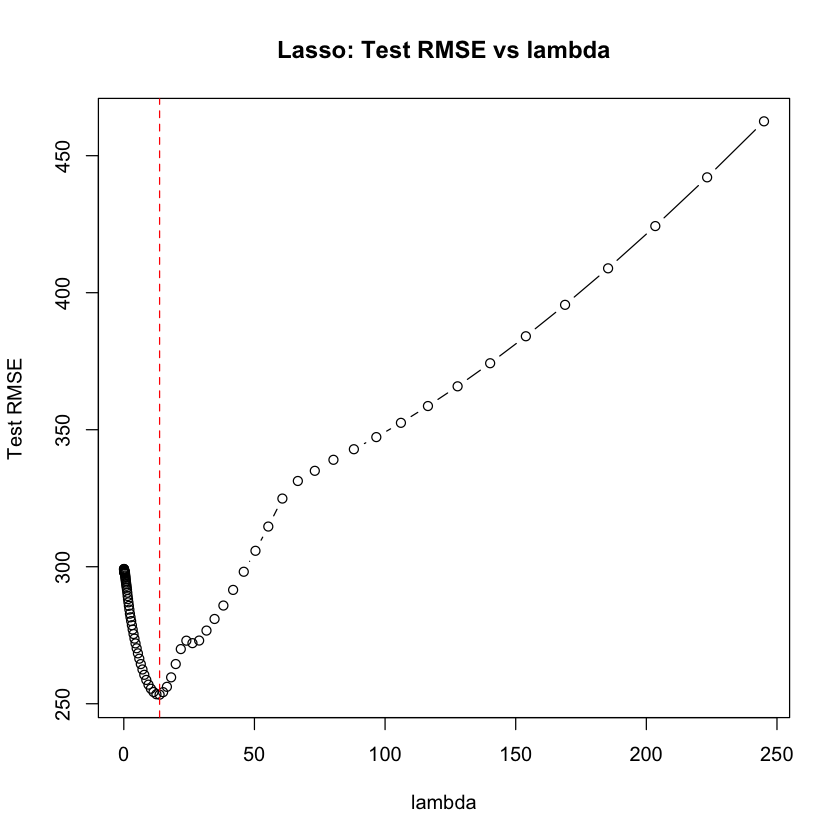

In [ ]:
## 2) Use the lambda sequence from that CV fit to evaluate test RMSE for each lambda in the sequence. This will give us a more complete picture of how the choice of lambda affects test performance, not just at the CV-selected lambda but across the entire range of lambdas considered.
lambda_seq <- lasso_model$lambda

rmse_vec <- numeric(length(lambda_seq))

for (i in seq_along(lambda_seq)) {
  lam <- lambda_seq[i]

  # fit lasso at this specific lambda
  lasso_model_fit <- glmnet(
    x      = as.matrix(train_data[, 1:15]),
    y      = train_data$Crime,
    alpha  = 1,
    family = "gaussian",
    lambda = lam
  )

  # predict on test_data
  lasso_pred <- predict(
    lasso_model_fit,
    newx = as.matrix(test_data[, 1:15])
  )

  # RMSE for this lambda
  rmse_vec[i] <- sqrt(mean((lasso_pred - test_data$Crime)^2))
}

## 3) Identify best lambda on test set
best_idx    <- which.min(rmse_vec)
best_lambda <- lambda_seq[best_idx]
best_rmse   <- rmse_vec[best_idx]

cat("Best lambda (by test RMSE):", best_lambda, "\n")
cat("Best RMSE:", best_rmse, "\n")

## 4) Plot RMSE vs lambda
plot(lambda_seq, rmse_vec, type = "b",
     xlab = "lambda",
     ylab = "Test RMSE",
     main = "Lasso: Test RMSE vs lambda")
abline(v = best_lambda, col = "red", lty = 2)

## 5) (Optional) Fit once more at best lambda and print coefficients
lasso_model_fit <- glmnet(
  x      = as.matrix(train_data[, 1:15]),
  y      = train_data$Crime,
  alpha  = 1,
  family = "gaussian",
  lambda = best_lambda
)

lasso_pred <- predict(
  lasso_model_fit,
  newx = as.matrix(test_data[, 1:15])
)

lasso_mse <- mean((lasso_pred - test_data$Crime)^2)
cat("Lasso MSE at best lambda:", lasso_mse, "\n")
cat("Lasso MSE at best lambda:", lasso_mse, "\n")
coefficients_lasso <- coef(lasso_model_fit)
print(coefficients_lasso)

In [ ]:
#using Elastic net to predict the crime rate. We will use the cv.glmnet function to perform cross-validation and find the optimal lambda value for the Elastic Net model. We will then use the predict function to make predictions on the test data and calculate the mean squared error and R-squared value for the Elastic Net model.

Elastic_net<-cv.glmnet(x=as.matrix(train_data[,1:15]),y= train_data$Crime,alpha=0.5,family = "gaussian")
Elastic_net$lambda.min
Elastic_net_fit<-glmnet(x=as.matrix(train_data[,1:15]),y = train_data$Crime,alpha=0.5,family = "gaussian",lambda = Elastic_net$lambda.min)

Elastic_net_pred<-predict(lasso_model_fit,as.matrix(test_data[,1:15]))

Elastic_net_mse<-mean((Elastic_net_pred-test_data$Crime)^2)

SST_Elastic_net <- sum((test_data$Crime - mean(test_data$Crime))^2)

cat("Elastic Net MSE: ",Elastic_net_mse,"\n")
cat("Elastic Net Rsquare: ",1-Elastic_net_mse/SST_Elastic_net,"\n")
coefficients_Elastic_net<-coef(lasso_model_fit)
print(coefficients_Elastic_net)

[1] 17.20712

Elastic Net MSE:  69949.58 
Elastic Net Rsquare:  0.9589661 
16 x 1 sparse Matrix of class "dgCMatrix"
                    s0
(Intercept)  913.79630
M             79.82502
So             .      
Ed           176.32583
Po1          306.53279
Po2            .      
LF             .      
M.F           16.76625
Pop          -64.81430
NW             .      
U1          -102.47765
U2           140.43995
Wealth         .      
Ineq         241.93305
Prob        -114.55733
Time           .      


In [118]:
# Stepwise regression to predict the crime rate. We will use the step function to perform stepwise regression and find the optimal model. We will then use the predict function to make predictions on the test data and calculate the mean squared error and R-squared value for the stepwise regression model.

Linear_regression <- lm(Crime ~ ., data = train_data)
step_lm  <- step(Linear_regression, direction = "both", trace = 0)

summary(step_lm)
pred_step <- predict(step_lm, newdata = test_data[,1:15])
rmse_step <- sqrt(mean((pred_step - test_data[,16])^2))
SST_step <- sum((test_data$Crime - mean(test_data$Crime))^2)


cat("Stepwise Regression RSME: ", (rmse_step), "\n")



Call:
lm(formula = Crime ~ M + Ed + Po1 + Pop + U1 + U2 + Ineq + Prob, 
    data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-249.52 -140.29   12.23   96.85  468.93 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   914.51      28.83  31.717  < 2e-16 ***
M              96.92      42.63   2.274 0.030315 *  
Ed            249.21      59.76   4.170 0.000239 ***
Po1           311.78      51.98   5.998 1.40e-06 ***
Pop           -84.82      41.16  -2.061 0.048060 *  
U1           -155.10      59.81  -2.593 0.014559 *  
U2            208.38      66.03   3.156 0.003628 ** 
Ineq          291.09      55.78   5.219 1.26e-05 ***
Prob         -128.06      43.77  -2.926 0.006491 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 177.9 on 30 degrees of freedom
Multiple R-squared:  0.8164,	Adjusted R-squared:  0.7674 
F-statistic: 16.67 on 8 and 30 DF,  p-value: 4.208e-09


Stepwise Regression RSME:  294.4194 
